NOTE: Ab tak tumne charts bina formal training ke banaye hain (box plots, histograms) — aaj se properly Matplotlib seekhenge: figure/axes structure, customization, aur line plots (time-series trends ke liye best).

1. Basic setup aur figure/axes concept:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    '../data/processed/step4_datatypes_fixed.csv',
    dtype={'Invoice': str, 'StockCode': str},
    parse_dates=['InvoiceDate']
)
df['LineTotal'] = df['Quantity'] * df['Price']

note: Matplotlib mein Figure poora "canvas" hai, Axes uske andar ek plot area hai. plt.plot() seedha use karna "quick way" hai, lekin fig, ax = plt.subplots() zyada control deta hai — professional code mein yehi use hota hai.

2. Simplest line plot — monthly revenue trend:

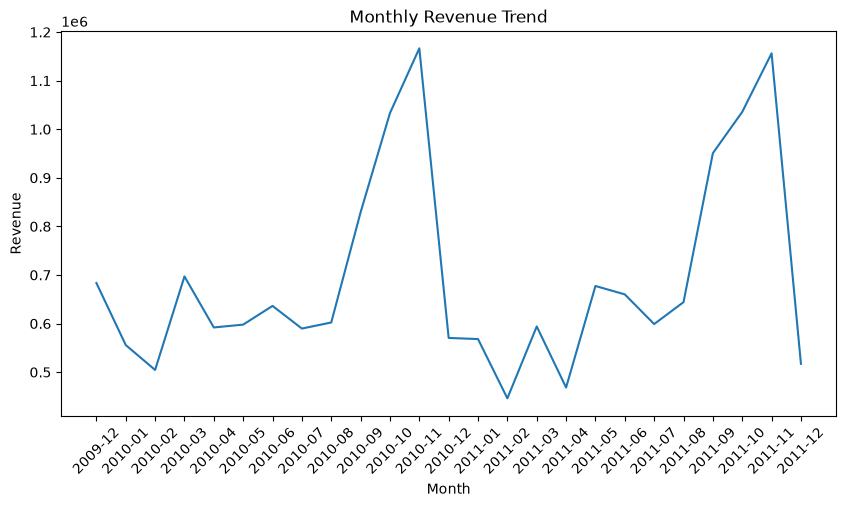

In [2]:
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['LineTotal'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.show()

3. fig, ax style (object-oriented approach — behtar practice, especially multiple plots ke liye):

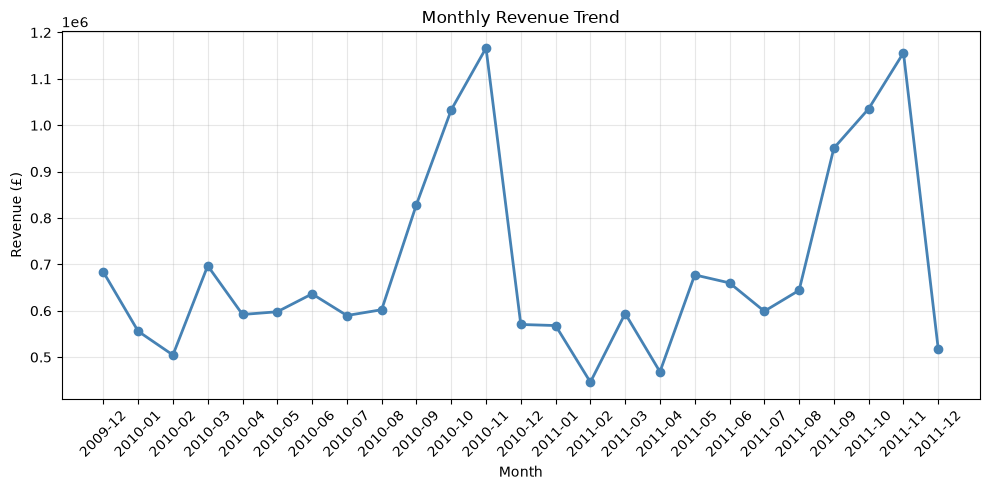

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linestyle='-', color='steelblue', linewidth=2)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.set_title('Monthly Revenue Trend')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

note: marker='o' har data point par dot dikhata hai, linestyle line ka type (solid/dashed), grid(alpha=0.3) halki grid lines add karta hai readability ke liye — yeh sab chhote customizations chart ko "professional" banate hain.

4. Multiple lines ek hi plot mein — Churned vs Not-Churned revenue trend compare karna:

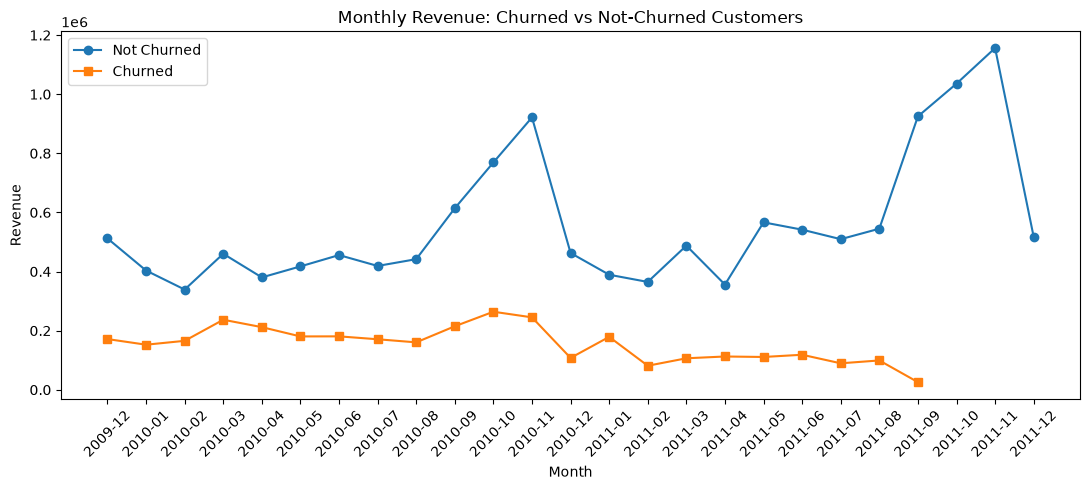

In [4]:
churn_labels = pd.read_csv('../data/processed/customer_churn_labeled.csv', usecols=['Customer ID', 'Churned'])
merged = df.merge(churn_labels, on='Customer ID', how='left')

monthly_by_churn = merged.groupby([merged['InvoiceDate'].dt.to_period('M'), 'Churned'])['LineTotal'].sum().unstack()
monthly_by_churn.index = monthly_by_churn.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_by_churn.index, monthly_by_churn[0], label='Not Churned', marker='o')
ax.plot(monthly_by_churn.index, monthly_by_churn[1], label='Churned', marker='s')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
ax.set_title('Monthly Revenue: Churned vs Not-Churned Customers')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

5. Running total / cumulative revenue (Day 14 ka LAG/cumsum concept, ab visual):

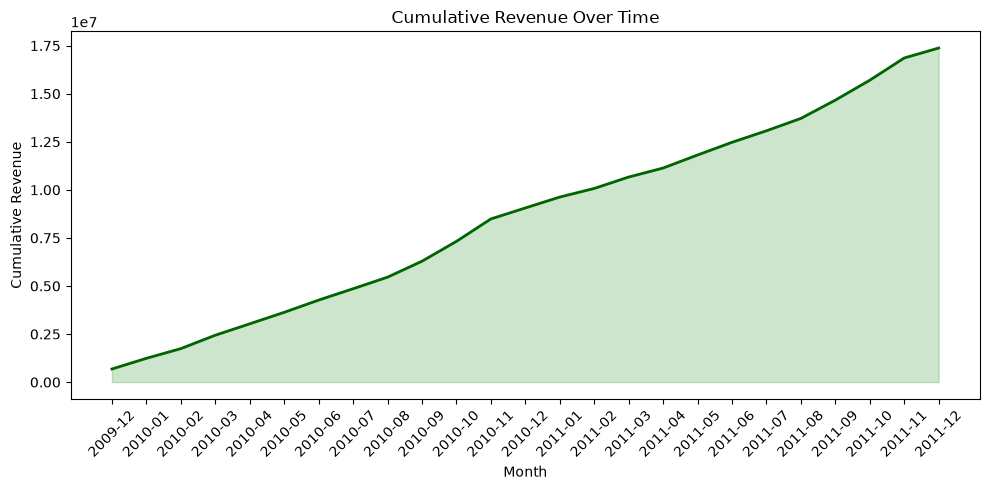

In [5]:
cumulative_revenue = monthly_revenue.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cumulative_revenue.index, cumulative_revenue.values, color='darkgreen', linewidth=2)
ax.fill_between(range(len(cumulative_revenue)), cumulative_revenue.values, alpha=0.2, color='green')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Revenue')
ax.set_title('Cumulative Revenue Over Time')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

6. Subplots — multiple charts ek grid mein (bahut common pattern reports ke liye):

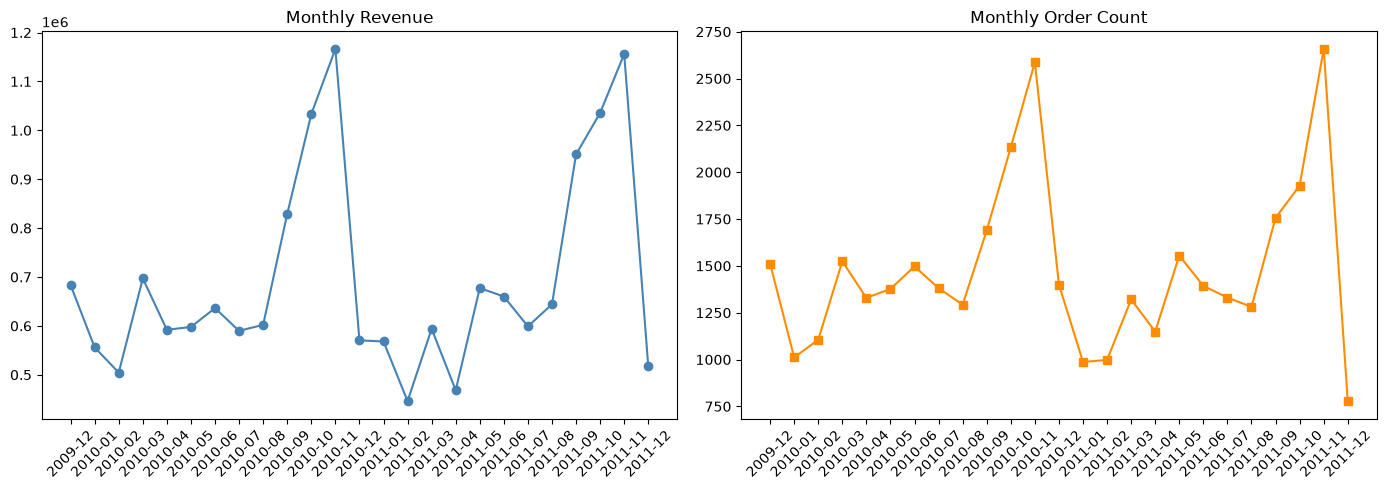

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue')
axes[0].set_title('Monthly Revenue')
axes[0].tick_params(axis='x', rotation=45)

monthly_orders = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Invoice'].nunique()
axes[1].plot(monthly_orders.index.astype(str), monthly_orders.values, marker='s', color='darkorange')
axes[1].set_title('Monthly Order Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

7. Chart save karna (README/portfolio ke liye image chahiye hogi):

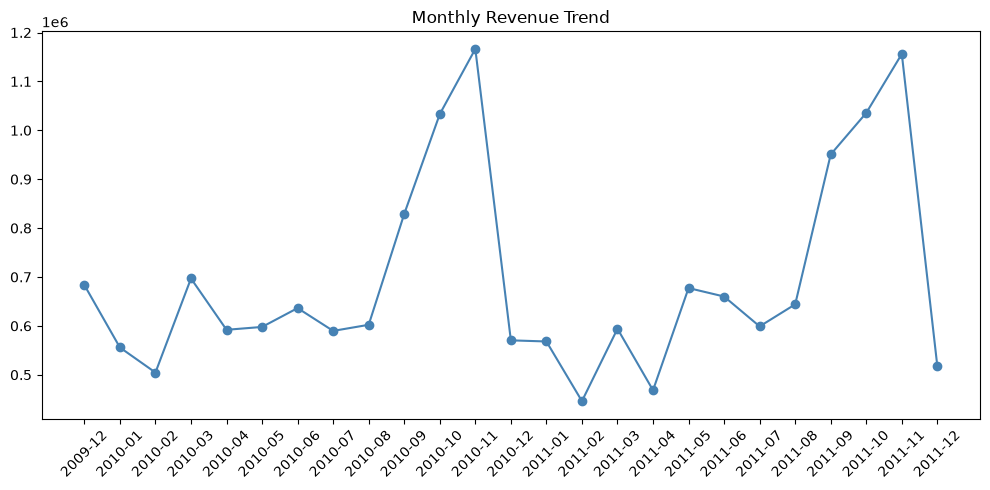

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='steelblue')
ax.set_title('Monthly Revenue Trend')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/monthly_revenue_trend.png', dpi=150)
plt.show()

Practice questions:

1. Daily revenue trend ka line plot banao (dt.date se group karke) — pata chalega kya koi specific weekday/date pattern dikhta hai.

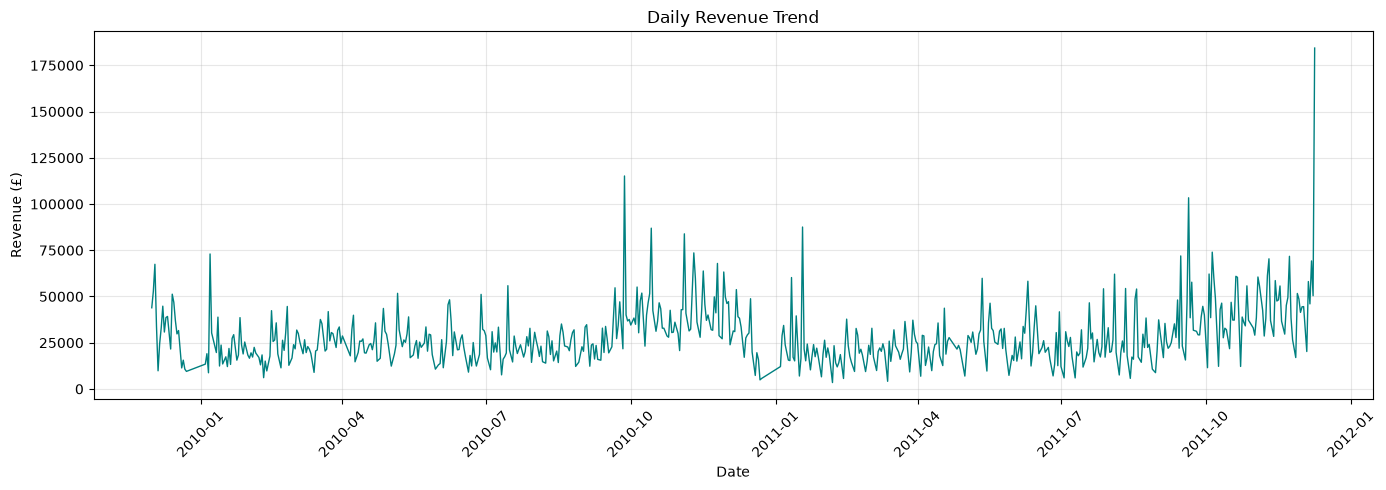

In [11]:
# 1. Daily revenue calculate karo
daily_revenue = df.groupby(df['InvoiceDate'].dt.date)['LineTotal'].sum()

# 2. fig, ax style mein plot banao
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_revenue.index, daily_revenue.values, color='teal', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.set_title('Daily Revenue Trend')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2. fig, ax style use karke ek line plot banao jisme Recency ka distribution over customer index dikhe (customers ko Recency se sort karke plot karo) — isse ek "sorted trend" dikhega.

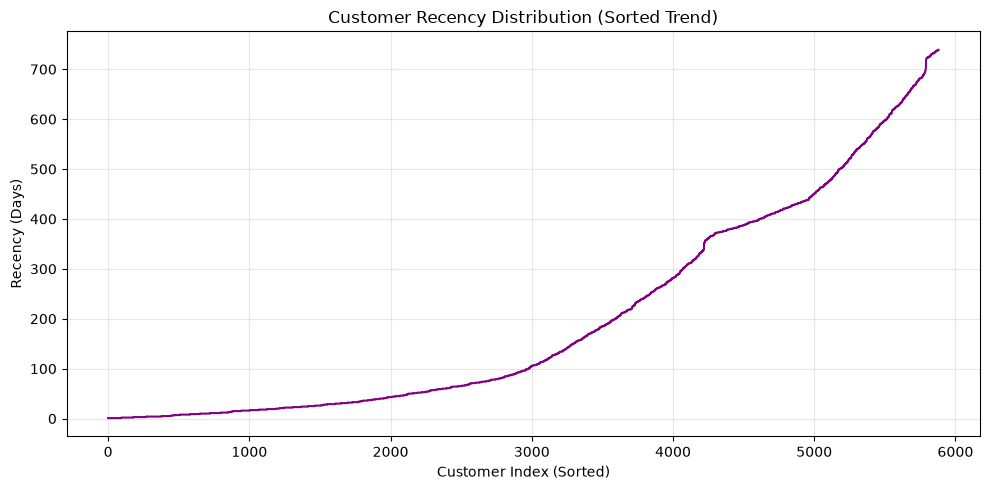

In [12]:
# 1. Snapshot date define karo (dataset ki max date se 1 din aage)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Customer-wise Recency calculate karo
recency_df = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (snapshot_date - recency_df['InvoiceDate']).dt.days

# 3. Recency ke basis par sort karo aur reset index karo
recency_df = recency_df.sort_values('Recency').reset_index(drop=True)

# 4. fig, ax style mein plot banao
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(recency_df.index, recency_df['Recency'], color='purple', linewidth=1.5)
ax.set_xlabel('Customer Index (Sorted)')
ax.set_ylabel('Recency (Days)')
ax.set_title('Customer Recency Distribution (Sorted Trend)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()